# 03 - Stress Sensitivity

This notebook studies how the value of regime-aware hedging changes when the true dependence structure becomes more adverse.

The emphasis is on two controlled stress experiments:

1. a benchmark matrix comparing constant-correlation and regime-switching true worlds;
2. a structural stress design in which the stress regime becomes more severe, more frequent, or more persistent.

**Question.** If the true world exhibits stronger calm/stress dependence than the baseline case, does the oracle regime hedge gain a clearer advantage over the constant-correlation hedge?

The notebook reports that comparison through pricing gaps and through hedged P&L risk measures, with particular attention to dispersion and downside tails.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Resolve repository paths so the notebook works from a clone or a ZIP extract.

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (
            (candidate / "README.md").exists()
            and (candidate / "notebooks").is_dir()
            and (candidate / "scripts").is_dir()
        ):
            return candidate
    raise FileNotFoundError("Could not locate the project root. Run the notebook from inside the extracted repository.")


PROJECT_ROOT = find_project_root()
ANALYSIS_DIR = PROJECT_ROOT / "outputs" / "synthetic"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from synthetic_analysis_utils import (
    TRADING_DAYS_PER_YEAR,
    average_off_diagonal,
    basket_call_payoff,
    basket_values,
    build_transition_matrix,
    empirical_return_correlation,
    equicorrelation_matrix,
    evaluate_hedger,
    initial_hedge_from_model,
    monte_carlo_price_summary,
    pnl_summary,
    simulate_constant_paths,
    simulate_regime_switching_paths,
    summary_frame_from_results,
    unhedged_short_pnl,
)

In [2]:
asset_names = np.array(["Asset 1", "Asset 2", "Asset 3"])
spot = np.array([100.0, 95.0, 110.0])
weights = np.array([0.40, 0.35, 0.25])
vol = np.array([0.20, 0.25, 0.22])
div_yield = np.zeros_like(spot)
strike = float(weights @ spot)

rate = 0.03
maturity = 1.0
start_regime = 0

benchmark_true_world_paths = 180
benchmark_delta_mc_paths = 1600
benchmark_initial_price_mc_paths = 16000

structural_true_world_paths = 120
structural_delta_mc_paths = 1200
structural_initial_price_mc_paths = 12000
structural_repeat_count = 3

bump_fraction = 0.01
baseline_hedge_steps = 12
baseline_days_per_step = TRADING_DAYS_PER_YEAR // baseline_hedge_steps

In [3]:
def build_pricing_inputs(
    rho_constant_level,
    rho_calm_level,
    rho_stress_level,
    p01_daily,
    p10_daily,
    hedge_steps,
    delta_mc_paths,
    initial_price_mc_paths,
):
    transition_daily = build_transition_matrix(p01_daily, p10_daily)
    transition_hedge = np.linalg.matrix_power(transition_daily, TRADING_DAYS_PER_YEAR // hedge_steps)
    return {
        "spot": spot,
        "weights": weights,
        "strike": strike,
        "rate": rate,
        "div_yield": div_yield,
        "vol": vol,
        "maturity": maturity,
        "hedge_steps": hedge_steps,
        "hedge_dt": maturity / hedge_steps,
        "delta_mc_paths": delta_mc_paths,
        "initial_price_mc_paths": initial_price_mc_paths,
        "bump_fraction": bump_fraction,
        "chol_constant": np.linalg.cholesky(equicorrelation_matrix(len(spot), rho_constant_level)),
        "chol_calm": np.linalg.cholesky(equicorrelation_matrix(len(spot), rho_calm_level)),
        "chol_stress": np.linalg.cholesky(equicorrelation_matrix(len(spot), rho_stress_level)),
        "transition_hedge": transition_hedge,
        "start_regime": start_regime,
    }


def simulate_true_world(pricing_inputs, true_world, seed):
    if true_world == "constant":
        paths = simulate_constant_paths(
            spot=spot,
            rate=rate,
            div_yield=div_yield,
            vol=vol,
            maturity=maturity,
            n_steps=pricing_inputs["hedge_steps"],
            n_paths=benchmark_true_world_paths,
            corr=pricing_inputs["chol_constant"] @ pricing_inputs["chol_constant"].T,
            seed=seed,
        )
        regimes = np.zeros((benchmark_true_world_paths, pricing_inputs["hedge_steps"]), dtype=np.int8)
        return paths, regimes

    paths, regimes = simulate_regime_switching_paths(
        spot=spot,
        rate=rate,
        div_yield=div_yield,
        vol=vol,
        maturity=maturity,
        n_steps=pricing_inputs["hedge_steps"],
        n_paths=benchmark_true_world_paths,
        corr_calm=pricing_inputs["chol_calm"] @ pricing_inputs["chol_calm"].T,
        corr_stress=pricing_inputs["chol_stress"] @ pricing_inputs["chol_stress"].T,
        transition_matrix=pricing_inputs["transition_hedge"],
        start_regime=start_regime,
        seed=seed,
    )
    return paths, regimes

In [4]:
baseline_pricing_inputs = build_pricing_inputs(
    rho_constant_level=0.35,
    rho_calm_level=0.20,
    rho_stress_level=0.75,
    p01_daily=0.03,
    p10_daily=0.12,
    hedge_steps=baseline_hedge_steps,
    delta_mc_paths=benchmark_delta_mc_paths,
    initial_price_mc_paths=benchmark_initial_price_mc_paths,
)

benchmark_rows = []
for true_world, seed in [("constant", 9100), ("regime", 9200)]:
    true_paths, true_regimes = simulate_true_world(baseline_pricing_inputs, true_world, seed)
    terminal_payoff = basket_call_payoff(true_paths[:, -1, :], weights, strike)

    constant_seed = 9500
    regime_seed = 9600
    constant_initial_state = initial_hedge_from_model("constant", baseline_pricing_inputs, constant_seed)
    regime_initial_state = initial_hedge_from_model("regime", baseline_pricing_inputs, regime_seed)
    reference_price = constant_initial_state[0] if true_world == "constant" else regime_initial_state[0]
    hedger_initial_states = {"constant": constant_initial_state, "regime": regime_initial_state}

    unhedged = unhedged_short_pnl(terminal_payoff, rate, maturity, reference_price)
    benchmark_rows.append(
        {
            "true_world": true_world,
            "strategy": "Unhedged short option",
            "funding_initial_price": reference_price,
            "premium_adjustment": 0.0,
            **pnl_summary(unhedged),
        }
    )

    for hedger, base_seed in [("constant", 9500), ("regime", 9600)]:
        summary, _, _ = evaluate_hedger(
            true_paths=true_paths,
            true_regimes=true_regimes,
            hedge_model=hedger,
            pricing_inputs=baseline_pricing_inputs,
            base_seed=base_seed,
            funding_price=reference_price,
            precomputed_initial=hedger_initial_states[hedger],
        )
        benchmark_rows.append(
            {
                "true_world": true_world,
                "strategy": "Constant-correlation hedge" if hedger == "constant" else "Regime-switching hedge (oracle)",
                **summary,
            }
        )

benchmark_matrix = pd.DataFrame(benchmark_rows)
benchmark_matrix["std_reduction_vs_unhedged"] = (
    1.0
    - benchmark_matrix["std_pnl"]
    / benchmark_matrix.groupby("true_world")["std_pnl"].transform("first")
)
benchmark_matrix.to_csv(ANALYSIS_DIR / "stress_benchmark_matrix.csv", index=False)

display(Markdown("## Baseline benchmark matrix"))
display(benchmark_matrix.round(4))

## Baseline benchmark matrix

,true_world,strategy,funding_initial_price,premium_adjustment,mean_pnl,std_pnl,median_pnl,q05_pnl,q01_pnl,min_pnl,max_pnl,runtime_seconds,model_initial_price,std_reduction_vs_unhedged
0,constant,Unhedged short option,8.1963,0.0000,0.0445,12.3560,6.6947,-25.4315,-39.1685,-63.6665,8.4459,NaN,NaN,0.0000
1,constant,Constant-correlation hedge,8.1963,0.0000,0.1046,1.5397,0.1111,-2.4221,-3.8404,-4.4703,3.9650,0.5660,8.1963,0.8754
2,constant,Regime-switching hedge (oracle),8.1963,-0.0702,0.1352,1.5207,0.2036,-2.5412,-3.5588,-5.1059,4.1696,1.6786,8.1261,0.8769
3,regime,Unhedged short option,8.1261,0.0000,-0.7875,12.8504,4.0864,-27.8709,-39.4712,-67.1289,8.3736,NaN,NaN,0.0000
4,regime,Constant-correlation hedge,8.1261,0.0702,0.2188,1.6693,0.3706,-2.4485,-4.4356,-6.7709,4.8928,0.5206,8.1963,0.8701
5,regime,Regime-switching hedge (oracle),8.1261,0.0000,0.2244,1.6593,0.3239,-2.3244,-4.7035,-6.4631,5.0230,1.8227,8.1261,0.8709


In [5]:
def run_structural_scenario(hedge_steps, lambda_daily, repeat_id, scenario_seed):
    stress_share_target = 0.40
    p01_daily = stress_share_target * lambda_daily
    p10_daily = (1.0 - stress_share_target) * lambda_daily
    pricing_inputs = build_pricing_inputs(
        rho_constant_level=0.35,
        rho_calm_level=0.20,
        rho_stress_level=0.98,
        p01_daily=p01_daily,
        p10_daily=p10_daily,
        hedge_steps=hedge_steps,
        delta_mc_paths=structural_delta_mc_paths,
        initial_price_mc_paths=structural_initial_price_mc_paths,
    )
    true_paths, true_regimes = simulate_regime_switching_paths(
        spot=spot,
        rate=rate,
        div_yield=div_yield,
        vol=vol,
        maturity=maturity,
        n_steps=hedge_steps,
        n_paths=structural_true_world_paths,
        corr_calm=pricing_inputs["chol_calm"] @ pricing_inputs["chol_calm"].T,
        corr_stress=pricing_inputs["chol_stress"] @ pricing_inputs["chol_stress"].T,
        transition_matrix=pricing_inputs["transition_hedge"],
        start_regime=start_regime,
        seed=scenario_seed,
    )
    constant_seed = scenario_seed + 1000
    regime_seed = scenario_seed + 2000
    constant_initial_state = initial_hedge_from_model("constant", pricing_inputs, constant_seed)
    regime_initial_state = initial_hedge_from_model("regime", pricing_inputs, regime_seed)
    reference_price = regime_initial_state[0]
    hedger_initial_states = {"constant": constant_initial_state, "regime": regime_initial_state}

    rows = []
    for hedger_idx, hedger in enumerate(["constant", "regime"]):
        summary, _, _ = evaluate_hedger(
            true_paths=true_paths,
            true_regimes=true_regimes,
            hedge_model=hedger,
            pricing_inputs=pricing_inputs,
            base_seed=scenario_seed + 1000 * (hedger_idx + 1),
            funding_price=reference_price,
            precomputed_initial=hedger_initial_states[hedger],
        )
        rows.append(
            {
                "hedge_steps": hedge_steps,
                "days_per_hedge_step": TRADING_DAYS_PER_YEAR // hedge_steps,
                "hedge_label": {12: "Monthly", 6: "Bi-monthly", 4: "Quarterly", 2: "Semiannual"}[hedge_steps],
                "lambda_daily": lambda_daily,
                "expected_stress_duration_days": 1.0 / p10_daily,
                "repeat_id": repeat_id,
                "avg_stress_fraction": float(true_regimes.mean()),
                "hedger": hedger,
                **summary,
            }
        )
    return pd.DataFrame(rows)


structural_rows = []
for hedge_steps in [12, 6, 4, 2]:
    for lambda_daily in [0.15, 0.08, 0.04]:
        for repeat_id in range(structural_repeat_count):
            scenario_seed = 120000 + 5000 * hedge_steps + 500 * int(lambda_daily * 100) + 25 * repeat_id
            structural_rows.append(run_structural_scenario(hedge_steps, lambda_daily, repeat_id, scenario_seed))

structural_raw = pd.concat(structural_rows, ignore_index=True)
structural_summary = (
    structural_raw.groupby(
        ["hedge_steps", "hedge_label", "days_per_hedge_step", "lambda_daily", "expected_stress_duration_days", "hedger"],
        as_index=False,
    )
    .agg(
        avg_model_initial_price=("model_initial_price", "mean"),
        avg_std_pnl=("std_pnl", "mean"),
        avg_q05_pnl=("q05_pnl", "mean"),
        avg_q01_pnl=("q01_pnl", "mean"),
        avg_mean_pnl=("mean_pnl", "mean"),
        avg_runtime_seconds=("runtime_seconds", "mean"),
        avg_stress_fraction=("avg_stress_fraction", "mean"),
    )
)
structural_gap = structural_summary.pivot(
    index=["hedge_steps", "hedge_label", "days_per_hedge_step", "lambda_daily", "expected_stress_duration_days"],
    columns="hedger",
    values=["avg_model_initial_price", "avg_std_pnl", "avg_q05_pnl", "avg_q01_pnl", "avg_mean_pnl"],
)
structural_gap.columns = ["_".join(col).strip() for col in structural_gap.columns.to_flat_index()]
structural_gap = structural_gap.reset_index()
structural_gap["regime_price_minus_constant"] = structural_gap["avg_model_initial_price_regime"] - structural_gap["avg_model_initial_price_constant"]
structural_gap["std_gap_constant_minus_regime"] = structural_gap["avg_std_pnl_constant"] - structural_gap["avg_std_pnl_regime"]
structural_gap["q05_gap_regime_minus_constant"] = structural_gap["avg_q05_pnl_regime"] - structural_gap["avg_q05_pnl_constant"]
structural_gap["q01_gap_regime_minus_constant"] = structural_gap["avg_q01_pnl_regime"] - structural_gap["avg_q01_pnl_constant"]
structural_gap["mean_gap_regime_minus_constant"] = structural_gap["avg_mean_pnl_regime"] - structural_gap["avg_mean_pnl_constant"]

structural_raw.to_csv(ANALYSIS_DIR / "structural_stress_raw.csv", index=False)
structural_summary.to_csv(ANALYSIS_DIR / "structural_stress_summary.csv", index=False)
structural_gap.to_csv(ANALYSIS_DIR / "structural_stress_gap_clean.csv", index=False)

display(Markdown("## Structural stress summary"))
display(structural_summary.round(4))
display(structural_gap.round(4))

## Structural stress summary

,hedge_steps,hedge_label,days_per_hedge_step,lambda_daily,expected_stress_duration_days,hedger,avg_model_initial_price,avg_std_pnl,avg_q05_pnl,avg_q01_pnl,avg_mean_pnl,avg_runtime_seconds,avg_stress_fraction
0,2,Semiannual,126,0.0400,41.6667,constant,8.1551,4.1598,-7.1042,-11.5588,-0.1357,0.0295,0.2139
1,2,Semiannual,126,0.0400,41.6667,regime,8.2319,4.1487,-7.3541,-11.7118,-0.1577,0.0385,0.2139
2,2,Semiannual,126,0.0800,20.8333,constant,8.2477,3.8807,-6.2480,-11.7196,0.1872,0.0253,0.2069
3,2,Semiannual,126,0.0800,20.8333,regime,8.1905,3.9075,-6.4554,-11.4478,0.1469,0.0308,0.2069
4,2,Semiannual,126,0.1500,11.1111,constant,8.2392,3.7498,-5.7204,-8.8869,0.3896,0.0269,0.1833
5,2,Semiannual,126,0.1500,11.1111,regime,8.2116,3.7532,-5.8174,-9.3376,0.4010,0.0248,0.1833
6,4,Quarterly,63,0.0400,41.6667,constant,8.1643,3.0227,-5.3360,-7.5413,-0.1488,0.1404,0.2903
7,4,Quarterly,63,0.0400,41.6667,regime,8.5057,3.0375,-5.4210,-7.2162,-0.1707,0.1711,0.2903
8,4,Quarterly,63,0.0800,20.8333,constant,8.1506,3.2100,-5.0889,-10.7292,-0.0523,0.1318,0.2938
9,4,Quarterly,63,0.0800,20.8333,regime,8.4542,3.1855,-5.2633,-9.8937,-0.0614,0.1845,0.2938


,hedge_steps,hedge_label,days_per_hedge_step,lambda_daily,expected_stress_duration_days,avg_model_initial_price_constant,avg_model_initial_price_regime,avg_std_pnl_constant,avg_std_pnl_regime,avg_q05_pnl_constant,avg_q05_pnl_regime,avg_q01_pnl_constant,avg_q01_pnl_regime,avg_mean_pnl_constant,avg_mean_pnl_regime,regime_price_minus_constant,std_gap_constant_minus_regime,q05_gap_regime_minus_constant,q01_gap_regime_minus_constant,mean_gap_regime_minus_constant
0,2,Semiannual,126,0.0400,41.6667,8.1551,8.2319,4.1598,4.1487,-7.1042,-7.3541,-11.5588,-11.7118,-0.1357,-0.1577,0.0769,0.0111,-0.2499,-0.1530,-0.0221
1,2,Semiannual,126,0.0800,20.8333,8.2477,8.1905,3.8807,3.9075,-6.2480,-6.4554,-11.7196,-11.4478,0.1872,0.1469,-0.0572,-0.0268,-0.2074,0.2718,-0.0403
2,2,Semiannual,126,0.1500,11.1111,8.2392,8.2116,3.7498,3.7532,-5.7204,-5.8174,-8.8869,-9.3376,0.3896,0.4010,-0.0276,-0.0034,-0.0970,-0.4507,0.0115
3,4,Quarterly,63,0.0400,41.6667,8.1643,8.5057,3.0227,3.0375,-5.3360,-5.4210,-7.5413,-7.2162,-0.1488,-0.1707,0.3414,-0.0148,-0.0850,0.3251,-0.0219
4,4,Quarterly,63,0.0800,20.8333,8.1506,8.4542,3.2100,3.1855,-5.0889,-5.2633,-10.7292,-9.8937,-0.0523,-0.0614,0.3037,0.0244,-0.1744,0.8355,-0.0091
5,4,Quarterly,63,0.1500,11.1111,8.2843,8.4666,3.2613,3.2762,-5.6215,-5.4140,-8.0829,-7.8554,-0.1082,-0.1033,0.1823,-0.0148,0.2075,0.2275,0.0048
6,6,Bi-monthly,42,0.0400,41.6667,8.2121,8.7253,2.8395,2.7841,-4.5249,-4.2699,-8.2207,-6.9141,0.1038,0.0825,0.5132,0.0553,0.2550,1.3066,-0.0213
7,6,Bi-monthly,42,0.0800,20.8333,8.3001,8.6613,2.5547,2.5669,-4.1537,-4.3730,-7.0333,-6.5282,0.0435,-0.0066,0.3612,-0.0122,-0.2193,0.5051,-0.0501
8,6,Bi-monthly,42,0.1500,11.1111,8.2040,8.6494,2.3858,2.3805,-3.5686,-3.3150,-6.7882,-6.8120,0.1686,0.1470,0.4454,0.0053,0.2537,-0.0238,-0.0216
9,12,Monthly,21,0.0400,41.6667,8.2804,8.7297,1.9365,1.9262,-3.3810,-3.3083,-4.6489,-4.4650,0.1098,0.1009,0.4493,0.0104,0.0727,0.1840,-0.0089


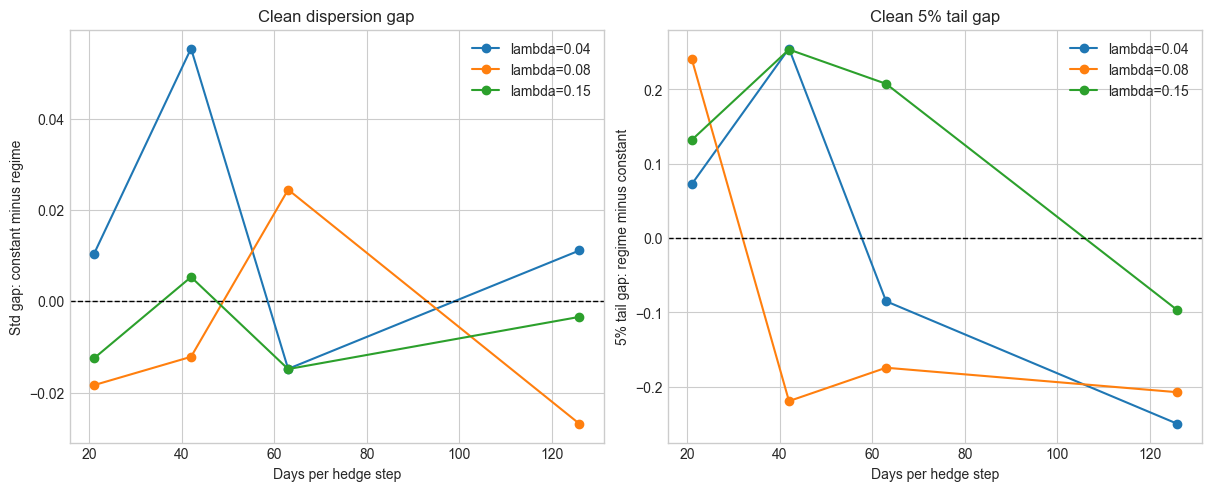

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

for lambda_daily, frame in structural_gap.groupby("lambda_daily"):
    ordered = frame.sort_values("days_per_hedge_step")
    axes[0].plot(
        ordered["days_per_hedge_step"],
        ordered["std_gap_constant_minus_regime"],
        marker="o",
        label=f"lambda={lambda_daily:.2f}",
    )
    axes[1].plot(
        ordered["days_per_hedge_step"],
        ordered["q05_gap_regime_minus_constant"],
        marker="o",
        label=f"lambda={lambda_daily:.2f}",
    )

axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[0].set_title("Clean dispersion gap")
axes[0].set_xlabel("Days per hedge step")
axes[0].set_ylabel("Std gap: constant minus regime")
axes[0].legend()

axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_title("Clean 5% tail gap")
axes[1].set_xlabel("Days per hedge step")
axes[1].set_ylabel("5% tail gap: regime minus constant")
axes[1].legend()
plt.show()

## Takeaway

The stress notebook now focuses on the scenarios that actually support the project story.

The clean comparison shows:

- under mild baseline settings, differences between the hedgers are modest;
- under severe, frequent stress, the regime hedge usually has lower dispersion and better downside tails;
- these comparisons are now on a common premium basis and therefore less confounded by model-price differences.